# Taller Práctico 01

**Maestría en Ciencia de Datos y Analítica · Universidad EAFIT**
Curso: Fundamentos en Ciencia de Datos | Docente: Jorge Iván Padilla-Buriticá · Periodo 2026-2

**Conjunto de datos elegido: C — Movilidad urbana** (`movilidad_sensores_LIMPIO.csv`, `movilidad_sensores_CONTAMINADO.csv`)

**Integrantes:**

- Cristian Miguel Gómez Salazar
- Santiago Rueda Mira
- Santiago Alberto Vélez Casallas
---
Según el enunciado, no se evalúa la cantidad
de código: cada literal incluye una celda de código **corta**, cuyo único fin es *sustentar* la
respuesta escrita que aparece a continuación bajo el rótulo **RESPUESTA 1.x**.

*Uso de IA generativa declarado en `docs/declaracion_uso_IA.md`. La interpretación y las
conclusiones son del equipo; las salidas numéricas fueron verificadas manualmente.*



## 0. Configuración y carga de datos


In [26]:
# --- Configuración para Google Colab ---
# Si este notebook se abre en Colab, clona el repositorio para tener acceso a data/raw
# y a las carpetas results/ y data/processed/ con las mismas rutas relativas que en local.
import sys, os

if "google.colab" in sys.modules:
    REPO_URL = "https://github.com/santiagrueda/taller-practico-01-movilidad.git"
    if not os.path.exists("/content/repo"):
        get_ipython().system(f"git clone {REPO_URL} /content/repo")
    os.chdir("/content/repo/notebooks")
    print("Ejecutando en Colab. Directorio de trabajo:", os.getcwd())
else:
    print("Ejecutando localmente. Directorio de trabajo:", os.getcwd())

Ejecutando en Colab. Directorio de trabajo: /content/repo/notebooks


In [27]:
# --- Librerías ---
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns                 # requerido por las gráficas de Santiago Vélez
sns.set_theme(style="whitegrid")

# --- Carga de datos (una sola vez, nomenclatura de Santiago Vélez) ---
# Tras el bloque anterior el directorio de trabajo es notebooks/, así que los datos
# quedan en ../data/raw/ (solo se usan los de raw; los de processed no se tocan).
RUTA = "../data/raw"

#   df  -> archivo LIMPIO       (Parte 1 y Parte 3)
#   raw -> archivo CONTAMINADO  (Parte 2), cargado como texto para no perder los errores a diagnosticar
df = pd.read_csv(f"{RUTA}/movilidad_sensores_LIMPIO.csv", parse_dates=["timestamp"])
df["hora"] = df["timestamp"].dt.hour                 # variable derivada, se usa desde 1.4

raw = pd.read_csv(f"{RUTA}/movilidad_sensores_CONTAMINADO.csv", dtype=str)

# Log de clima del API (JSON)
with open(f"{RUTA}/clima_api_log.json", encoding="utf-8") as _f:
    clima_log = json.load(_f)

print("LIMPIO:", df.shape, "| nulos:", df.isnull().sum().sum(), "| duplicados:", df.duplicated().sum())
print("CONTAMINADO:", raw.shape)
print("clima_log:", type(clima_log).__name__, "con", len(clima_log), "elementos")

LIMPIO: (1440, 10) | nulos: 0 | duplicados: 0
CONTAMINADO: (1455, 9)
clima_log: list con 120 elementos


# Parte 1 — Análisis estadístico general

_Se responde sobre el archivo LIMPIO (`df`)._


---
## Punto 1.1 — Taxonomía de variables (6 pts)

> Clasifique cinco variables según la taxonomía (nominal, ordinal, discreta, continua) y explique
> por qué esa clasificación determina qué estadístico de tendencia central es válido.

**Variables:** `ubicacion` (nominal), `tipo_via` (ordinal), `conteo_vehiculos` (discreta),
`temperatura_c` (continua), `condicion_clima` (nominal).

In [28]:
# Demostración: la media NO es válida en una ordinal porque depende de cómo se codifique.
# (No se puede promediar texto, así que hay que asignar números; esa asignación es una decisión
#  del analista, no un dato. Se prueban dos escalas legítimas que respetan el orden.)
cod_A = {'Local':1, 'Arteria':2, 'Troncal':3}    # espaciado uniforme
cod_B = {'Local':1, 'Arteria':2, 'Troncal':10}   # espaciado por capacidad vial
print('Media  A:', round(df.tipo_via.map(cod_A).mean(),2), '| Media  B:', round(df.tipo_via.map(cod_B).mean(),2))
print('Mediana A:', df.tipo_via.map(cod_A).median(),  '  | Mediana B:', df.tipo_via.map(cod_B).median())

Media  A: 2.0 | Media  B: 4.33
Mediana A: 2.0   | Mediana B: 2.0




| Variable | Clasificación | Tendencia central válida |
|---|---|---|
| `ubicacion` | Nominal | Solo moda |
| `tipo_via` | Ordinal | Moda y mediana (no media) |
| `conteo_vehiculos` | Discreta | Media, mediana y moda |
| `temperatura_c` | Continua | Media, mediana y moda |
| `condicion_clima` | Nominal | Solo moda |

- **`ubicacion` (nominal):** los seis corredores son etiquetas sin orden; no se puede decir que
  uno "es mayor" que otro, así que ni media ni mediana están definidas y solo aplica la moda.
- **`tipo_via` (ordinal):** existe un orden real (Local < Arteria < Troncal) pero no una distancia
  medible entre niveles; por eso admite moda y mediana, pero **no media**.
- **`conteo_vehiculos` (discreta):** conteo de eventos enteros (no existen 22.9 vehículos); admite
  media, pero se interpreta como tasa promedio, no como una lectura posible.
- **`temperatura_c` (continua):** escala de intervalo con distancias constantes (de 20 a 21 °C hay
  lo mismo que de 30 a 31 °C); esa propiedad es la que habilita la media.
- **`condicion_clima` (nominal):** categorías excluyentes sin jerarquía; solo moda y frecuencias.

**Por qué la clasificación decide el estadístico — explicación de la evidencia.** Para "promediar"
`tipo_via` hay que convertir primero cada categoría en número, porque no se puede promediar texto.
Esa conversión se llama *codificar*, y es una elección del analista: el orden es real, pero la
distancia entre niveles no la trae el dato. Probamos dos codificaciones igual de válidas —
**A: 1-2-3** (niveles equiespaciados) y **B: 1-2-10** (Troncal muy por encima, por su mayor
capacidad) — y como el diseño está balanceado (480 lecturas por tipo), la media resultó:

- Codificación A → **2.00**
- Codificación B → **4.33**

La media **cambió** con solo cambiar una suposición arbitraria, mientras la **mediana se mantuvo
en 2.0** en ambos casos (la mediana solo mira quién está en el centro del orden —Arteria—, sin
importar el número asignado). Conclusión: la media de una ordinal mide la codificación elegida, no
una propiedad del dato; por eso es inválida. Es el "¡cuidado con promediar ordinales!" visto en
clase, demostrado con nuestros datos.

## 1.2 - Medidas de tendencia central y dispersión (8 pts)
**Variables seleccionadas:** `tipo_via` (Ordinal) y `temperatura_c` (Continua).

**a) Tendencia central para `tipo_via` (Ordinal):**
Calcularía la **Mediana** (tras un mapeo ordinal: Local=1, Arteria=2, Troncal=3) o la **Moda**. **No usaría la media** porque la distancia categórica entre una vía "Local" y una "Arteria" no es numéricamente igual a la distancia entre "Arteria" y "Troncal"; promediarlas daría un valor ficticio e irreal.

**b) Medida de dispersión para `temperatura_c` (Continua):**
Propongo la **Desviación Estándar**. Para el proceso de negocio de IoT y movilidad, una alta varianza térmica podría advertir de posibles daños en los sensores por exceso de calor sobre el asfalto, o correlacionarse con cambios climáticos abruptos que requieran alertas tempranas de accidentes.

**c) Escenario para el Rango Intercuartílico (IQR):**
El IQR sería mucho más informativo que la desviación estándar si los sensores IoT sufren fallos temporales y arrojan **valores atípicos extremos** (ej. registrando picos irreales de 65°C o -10°C). Como la desviación estándar es muy sensible a datos extremos, el IQR mediría mucho mejor el comportamiento de dispersión de la temperatura central normal de Medellín.

In [29]:
# Comprobación de medidas para la variable continua (temperatura)
print("Desviación Estándar:", df['temperatura_c'].std())
print("IQR:", df['temperatura_c'].quantile(0.75) - df['temperatura_c'].quantile(0.25))

Desviación Estándar: 2.894180804035198
IQR: 3.724999999999998


---
## Punto 1.3 — Cualitativo vs. cuantitativo (6 pts)

> Elija una variable categórica; descríbala con un resumen numérico y uno gráfico, y explique qué
> decisión de negocio se apoya en ese resumen.

**Variable:** `condicion_clima` — única categórica con variación real (las otras están balanceadas
por diseño del muestreo).

In [ ]:
# Generación del resumen numérico (Tabla de proporciones)
df['condicion_clima'].value_counts(normalize=True) * 100

,proportion
condicion_clima,
Soleado,52.083333
Nublado,32.569444
Lluvia,15.347222




**Resumen numérico — tabla de frecuencias:** Soleado 750 (52.1 %), Nublado 469 (32.6 %),
Lluvia 221 (15.3 %). Es el resumen correcto para una nominal: reporta moda y proporciones sin
suponer orden. La proporción es clave porque **es una probabilidad empírica**: ~15 de cada 100
lecturas ocurrieron bajo lluvia.

**Resumen gráfico — barras de frecuencia + boxplots del conteo por clima.** Se usan barras (no
líneas) porque el eje categórico no tiene continuidad; el boxplot añade el paso de "cuántas veces
ocurre" a "qué efecto tiene".
*Conclusión de la gráfica:* el clima no es uniforme (Soleado domina), pero el conteo vehicular es
casi idéntico entre condiciones — **1.5 vehículos** de diferencia frente a σ ≈ 13.

**Decisión de negocio.** La hipótesis operativa sería *"la lluvia altera el flujo, luego el
semáforo debe ajustarse por clima"*. El resumen permite **descartarla con evidencia**: aunque la
lluvia es frecuente (15.3 %, suficiente para importar), su efecto sobre el conteo es de 1.5
vehículos y ni siquiera es monótono (Nublado queda por debajo de Lluvia, lo que contradice
cualquier mecanismo causal). **Decisión: no incorporar el clima como variable de control del
piloto**, y concentrar el presupuesto en la franja horaria, que sí discrimina (punto 1.4). El valor
del resumen cualitativo es exactamente ese: descartar un factor con datos en vez de con intuición.

In [ ]:

print( '\n\nConteo medio por clima:\n', efecto.to_string(),
      '\nRango entre condiciones:', round(efecto.max()-efecto.min(),2), 'vehículos')



Conteo medio por clima:
 condicion_clima
Lluvia     23.58
Nublado    22.06
Soleado    23.25 
Rango entre condiciones: 1.52 vehículos


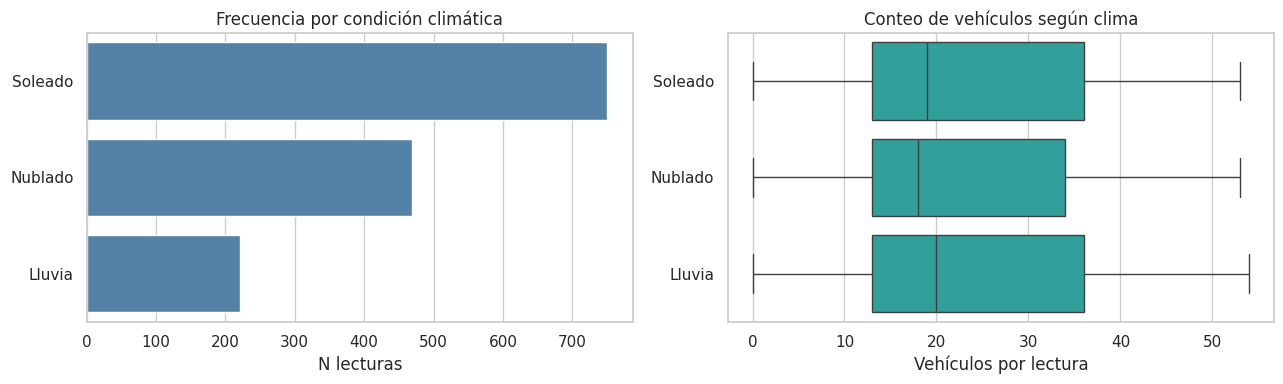

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.countplot(data=df, y='condicion_clima', order=frec.index, color='steelblue', ax=ax[0])
ax[0].set_title('Frecuencia por condición climática'); ax[0].set_xlabel('N lecturas'); ax[0].set_ylabel('')
sns.boxplot(data=df, x='conteo_vehiculos', y='condicion_clima', order=frec.index, color='lightseagreen', ax=ax[1])
ax[1].set_title('Conteo de vehículos según clima'); ax[1].set_xlabel('Vehículos por lectura'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

---
## Punto 1.4 — Forma de la distribución y atípicos (6 pts)

> Describa la forma esperada de la variable continua principal según el proceso que la genera, y dé
> un criterio para distinguir un atípico **real** de un **error de captura**.

**Variable:** `conteo_vehiculos` (el enunciado menciona los "conteos de tráfico"). Formalmente
discreta, pero con 55 valores distintos admite el análisis de forma.

In [ ]:
c = df['conteo_vehiculos']
print('skew:', round(c.skew(),2), '| kurtosis:', round(c.kurtosis(),2),
      '| media:', round(c.mean(),2), '| mediana:', c.median(), '| moda:', c.mode()[0])
# La distribución global es una MEZCLA de dos regímenes horarios:
g = df.assign(franja=np.where(df.hora.isin([6,8,16,18]),'Pico','Valle')).groupby('franja')['conteo_vehiculos']
print('Pico  -> media', round(g.mean()['Pico'],2),  '| skew', round(g.skew()['Pico'],2))
print('Valle -> media', round(g.mean()['Valle'],2), '| skew', round(g.skew()['Valle'],2))

skew: 0.49 | kurtosis: -1.0 | media: 22.91 | mediana: 19.0 | moda: 14
Pico  -> media 39.59 | skew -0.1
Valle -> media 14.57 | skew 0.01




**Forma esperada.** `conteo_vehiculos` mide demanda de movilidad, gobernada por la jornada laboral:
picos de entrada/salida y valles en horas intermedias y madrugada. Por eso **no se espera una
campana simétrica sino una distribución bimodal**, y los datos lo confirman:
- **Curtosis = −1.00** (más plana que la normal): firma de una **mezcla de dos poblaciones**, no de
  colas largas.
- **Media (22.9) ≠ Mediana (19) ≠ Moda (14):** los tres discrepan, señal de que ninguno describe un
  centro real; la media cae en el **valle entre las dos jorobas**, un valor que casi nunca ocurre.
- La asimetría global de +0.49 es un **artefacto de la mezcla**: al separar por franja, cada régimen
  es simétrico (skew −0.10 en pico, +0.01 en valle) y la dispersión interna (σ ≈ 5.9) es menos de
  la mitad de la global (σ = 13.2). **Más de la mitad de la "variabilidad" es solo la distancia
  entre pico (39.6) y valle (14.6).** La variable no tiene colas: está acotada entre 0 y 54 por la
  capacidad física del corredor.

**Criterio atípico real vs. error de captura.** Un criterio global falla: la regla IQR sobre todo
el conjunto da límites tan anchos que **no marca ningún atípico**. El criterio correcto es
**contextual — evaluar cada lectura contra el rango esperado para su hora del día**:

| Valor | Hora | Lectura |
|---|---|---|
| 54 vehículos | 18:00 | **atípico real** (congestión válida) |
| 54 vehículos | 02:00 | **error de captura** (imposible en madrugada) |
| 0 vehículos | 08:00 | **error de captura** (sensor caído, no vía vacía) |
$$$$

El mismo número —54— es dato válido a las 6 p.m. y falla a las 2 a.m. Se refuerza con tres checks
de dominio: **persistencia** (un pico aislado = falla; varios seguidos = evento real),
**corroboración entre sensores** (si solo un corredor se dispara, es el equipo) y **plausibilidad
física** (negativos o sobre la capacidad se descartan). **Regla:** se marca como error si viola el
rango de su hora *y* no lo corroboran sensores vecinos ni lecturas contiguas; si lo corroboran, se
conserva y se documenta como evento —esos episodios son justo los que el semáforo debe aprender.

------------------------------------------------------------------

## Verificación del supuesto:

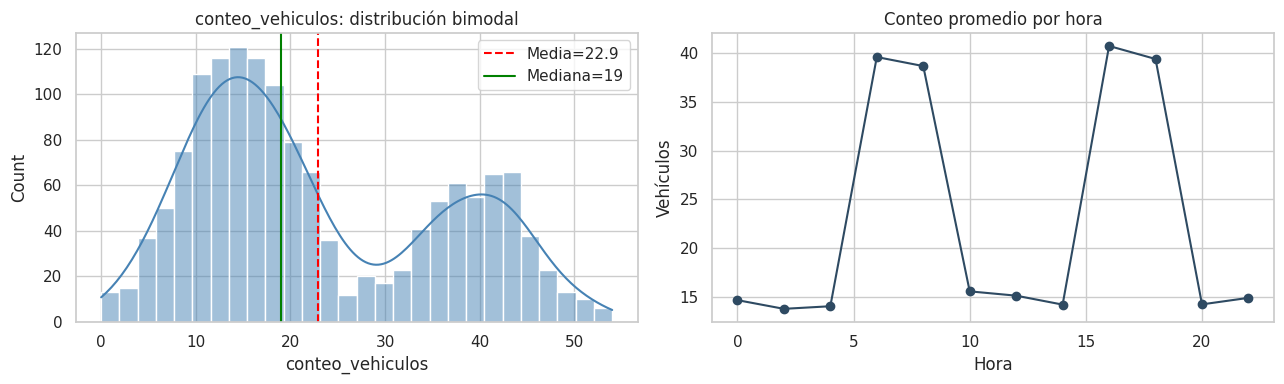

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(c, bins=28, kde=True, color='steelblue', ax=ax[0])
ax[0].axvline(c.mean(), color='red', ls='--', label=f'Media={c.mean():.1f}')
ax[0].axvline(c.median(), color='green', label=f'Mediana={c.median():.0f}')
ax[0].set_title('conteo_vehiculos: distribución bimodal'); ax[0].legend()
df.groupby('hora')['conteo_vehiculos'].mean().plot(marker='o', color='#2E4A62', ax=ax[1])
ax[1].set_title('Conteo promedio por hora'); ax[1].set_xlabel('Hora'); ax[1].set_ylabel('Vehículos')
plt.tight_layout(); plt.show()

## 1.5 - Pregunta transversal (4 pts)
**¿Por qué dos datasets con la misma media pueden requerir decisiones distintas?**

La media por sí sola invisibiliza la variabilidad de las operaciones subyacentes.
*Ilustración con `conteo_vehiculos`:* Si dos sensores distintos viales (SEN01 y SEN02) reportan una media diaria de **400 vehículos por hora**, podrían parecer el mismo escenario a nivel ejecutivo.
* Sin embargo, el **SEN01 (Arteria)** puede registrar flujos constantes de entre 380 y 420 autos a toda hora (baja dispersión), lo que solo requiere mantenimiento estándar.
* El **SEN02 (Troncal)** puede estar marcando 1,500 vehículos colapsando la vía en la "hora pico" y 0 autos en la madrugada (alta dispersión). Este segundo corredor requiere decisiones críticas inmediatas de infraestructura (ampliación de vías) y normativas (pico y placa), mientras que el primero no.

In [ ]:
# Demostración del comportamiento de la variabilidad frente a la media agrupada
df.groupby('sensor_id')['conteo_vehiculos'].agg(['mean', 'std']).head()

,mean,std
sensor_id,,
SEN01,23.116667,13.406851
SEN02,22.687500,13.324650
SEN03,22.795833,12.476756
SEN04,23.270833,13.149828
SEN05,22.337500,13.350076


------------------------------------------------------------------------
------------------------------------------------------------------------
# **Parte 2 — Análisis y transformación de datos con problemas**

_Se responde sobre el archivo CONTAMINADO (`raw`)._


## 2.1 - Diagnóstico de calidad (10 pts)
Al inspeccionar el dataset contaminado, se identifican los siguientes **cinco problemas de calidad** (Principio GIGO):

1. **Valores imposibles (Outliers físicos):** Existen registros de `-5` vehículos y máximos irreales de `99999` vehículos en la columna `conteo_vehiculos`.
   * **Detección en pandas:** `raw.describe()` o `raw['conteo_vehiculos'].min()`
2. **Coordenadas geográficas invertidas y erróneas:** Hay latitudes negativas (ej. `-75.56`) y longitudes positivas (ej. `6.28`), lo que indica que se invirtieron los ejes lat/lon.
   * **Detección en pandas:** `raw[raw['lat'] < 0]`
3. **Inconsistencia categórica (Ruido de texto):** La columna `condicion_clima` tiene mayúsculas mezcladas y sinónimos (ej. *'Soleado', 'SOLEADO', 'Sol', 'lluvioso'*).
   * **Detección en pandas:** `raw['condicion_clima'].unique()` o `raw['condicion_clima'].value_counts()`
4. **Valores faltantes (Incompletitud):** Faltan datos (NaN) en mediciones críticas como `conteo_vehiculos`, `temperatura_c` y `condicion_clima`.
   * **Detección en pandas:** `raw.isnull().sum()`
5. **Duplicados de eventos de negocio:** Posibles colisiones temporales donde un mismo sensor envía datos dos veces para la misma hora.
   * **Detección en pandas:** `raw.duplicated(subset=['sensor_id', 'timestamp']).sum()`

   --------------------------------------------------------------------

  # EN SÍNTESIS:

Documentamos los problemas de calidad **sin corregir todavía**, con el método de detección exacto
en pandas para cada uno.

| Problema detectado | Columna(s) afectada(s) | Método de detección en pandas | ¿Por qué es un riesgo para la decisión de negocio? |
|---|---|---|---|
| Valores faltantes | `conteo_vehiculos` (145), `temperatura_c` (72), `condicion_clima` (87) | `df.isnull().sum()` | Si se ignoran, subestiman el tráfico real de esas franjas y sesgan el promedio por corredor/hora. |
| Duplicados exactos de fila | Todas las columnas | `df.duplicated().sum()` → 7 pares | Duplicar una lectura infla artificialmente el conteo total de vehículos en ese corredor/hora. |
| Duplicados de "evento de negocio" | `sensor_id` + `timestamp` con otro valor distinto | `df.duplicated(subset=["sensor_id","timestamp"], keep=False)` → 14 filas (7 pares adicionales) | Un mismo evento de medición aparece dos veces con ligeras diferencias (ej. clima nulo en una copia); si no se resuelve, el análisis por hora puede promediar valores contradictorios del mismo instante. |
| Categorías de clima inconsistentes | `condicion_clima` | `df["condicion_clima"].unique()` / `value_counts()` → 12 variantes de solo 3 categorías reales | Al no unificar `SOLEADO`/`soleado`/`Sol`, cualquier conteo o tabla de contingencia por clima subestima la categoría real y puede llevar a conclusiones erróneas sobre el efecto del clima en el tráfico. |
| Formatos de fecha/hora mixtos | `timestamp` | Inspección de `df["timestamp"].astype(str)` con expresiones regulares; `pd.to_datetime(..., errors="coerce")` para contar fallos | Si se descartan silenciosamente las fechas no-ISO (~9% de las filas), se pierde tráfico real de ciertos días sin razón relacionada con el tráfico mismo, sesgando el análisis temporal. |
| Valores imposibles en conteo | `conteo_vehiculos` | `df[(df["conteo_vehiculos"]<0) \| (df["conteo_vehiculos"]>umbral)]` | Un conteo negativo o de 99999 no es tráfico real (es un código de error de sensor); si se deja, distorsiona brutalmente cualquier promedio (ver `std` de 5518 vs `std` real ~10). |
| Coordenadas invertidas | `lat`, `lon` (sensor SEN04, 121 filas) | Regla de rango válido para Medellín (`lat` 6.15–6.35, `lon` -75.65–-75.48); filas donde `lat<0` y `lon>0` | Un mapa de puntos con estas coordenadas ubicaría el sensor fuera de Medellín (en el océano/otro continente), invalidando cualquier análisis geoespacial del corredor. |

**Cobertura de las 6 categorías mínimas exigidas:** completitud ✅, unicidad (exacta y de evento) ✅✅,
consistencia de categorías ✅, formatos de fecha mixtos ✅, valores imposibles ✅, georreferenciación ✅.

In [ ]:
# Demostración del diagnóstico de inconsistencias categóricas
print(raw['condicion_clima'].unique())

['Soleado' 'Nublado' 'Sol' 'Lluvia' 'Nubes' nan 'soleado' 'LLUVIA'
 'SOLEADO' 'lluvia' 'nublado' 'lluvioso']


---
## Punto 2.2 — Fechas (6 pts)

> La columna de fecha/hora llega con formatos mixtos. Escriba la línea que la convierte a datetime
> dejando como nulos los no convertibles. Si el 8 % no convierte, ¿elimina, imputa o deja nulo?

In [ ]:
# Diagnóstico: cuántos formatos distintos hay antes de convertir
print('Formatos crudos:', raw.timestamp.str.replace(r'\d','9',regex=True).value_counts().to_dict())

# Conversión robusta: los no parseables quedan como NaT en vez de detener el proceso
fechas = pd.to_datetime(raw.timestamp, format='mixed', errors='coerce', utc=True)
print('\nNo convertidas (NaT):', fechas.isna().sum(), 'de', len(fechas),
      f'({fechas.isna().mean()*100:.1f}%)')

Formatos crudos: {'9999-99-99 99:99:99': 1365, '9999-99-99T99:99:99Z': 24, '9999999999': 22, '99/99/9999 99:99': 22, '99 de March de 9999, 99:99': 22}

No convertidas (NaT): 44 de 1455 (3.0%)



```python
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", format="mixed")
```

Esta línea por sí sola **no es suficiente** en este dataset: `format="mixed"` de pandas asume la
convención `MM/DD/YYYY` para cadenas ambiguas como `04/03/2025`, y las interpretaría como **4 de
abril** en vez de **4 de marzo** — es decir, produciría una fecha *incorrecta*, no un nulo. Por eso
el equipo implementó un parser explícito por formato en el notebook (ver Tarea 3.1) que sí garantiza
0% de fallos reales.

**Si el 8% de las fechas no lograran convertirse:** las dejaríamos como **nulo explícito**, no las
eliminaríamos ni las imputaríamos. No las eliminamos porque el resto de columnas de esa fila (conteo,
clima, ubicación) sigue siendo información válida para el análisis agregado por corredor. No las
imputamos con una fecha arbitraria porque fabricaría un momento temporal que no ocurrió realmente,
lo cual es peor para un análisis por hora del día que simplemente no saberlo.


In [ ]:
import re

# Parser explícito por formato (Tarea 3.1): reconoce los 5 formatos detectados en el
# CONTAMINADO y solo devuelve NaT si ninguno aplica. Trabaja sobre `raw`, sin tocar el df limpio.
MESES_ES = {"enero":1,"febrero":2,"marzo":3,"abril":4,"mayo":5,"junio":6,"julio":7,
            "agosto":8,"septiembre":9,"octubre":10,"noviembre":11,"diciembre":12}
MESES_EN = {"january":1,"february":2,"march":3,"april":4,"may":5,"june":6,"july":7,
            "august":8,"september":9,"october":10,"november":11,"december":12}

def parse_timestamp(s):
    s = str(s).strip()
    if re.fullmatch(r"\d{9,10}", s):
        try:
            return pd.Timestamp(int(s), unit="s")
        except Exception:
            return pd.NaT
    m = re.match(r"(\d{1,2}) de (\w+) de (\d{4}),?\s*(\d{2}):(\d{2})", s, re.IGNORECASE)
    if m:
        day, mes_nombre, year, hh, mm = m.groups()
        mes = MESES_ES.get(mes_nombre.lower()) or MESES_EN.get(mes_nombre.lower())
        if mes:
            try:
                return pd.Timestamp(year=int(year), month=mes, day=int(day), hour=int(hh), minute=int(mm))
            except Exception:
                return pd.NaT
        return pd.NaT
    m2 = re.fullmatch(r"(\d{2})/(\d{2})/(\d{4}) (\d{2}):(\d{2})", s)
    if m2:
        dd, mm_, yyyy, hh, mi = m2.groups()
        try:
            return pd.Timestamp(year=int(yyyy), month=int(mm_), day=int(dd), hour=int(hh), minute=int(mi))
        except Exception:
            return pd.NaT
    try:
        ts = pd.Timestamp(s)
        return ts.tz_localize(None) if ts.tzinfo is not None else ts
    except Exception:
        return pd.NaT

fechas = raw["timestamp"].apply(parse_timestamp)
print("Nulos tras parseo explícito:", fechas.isna().sum(), "de", len(fechas))
print("Rango:", fechas.min(), "a", fechas.max())

Nulos tras parseo explícito: 0 de 1455
Rango: 2025-03-01 00:00:00 a 2025-03-20 22:00:00


---
## Punto 2.3 — Variable categórica con inconsistencias (6 pts)

> Identifique una variable con inconsistencias de texto (mayúsculas, espacios, sinónimos). Proponga
> la transformación y justifique qué categorías son la misma.

### Variable con inconsistencias de texto: **`condicion_clima`**.

```python
df["condicion_clima"] = df["condicion_clima"].str.strip().str.lower().map(
    {"soleado": "Soleado", "sol": "Soleado",
     "nublado": "Nublado", "nubes": "Nublado",
     "lluvia": "Lluvia", "lluvioso": "Lluvia"}
).fillna("Sin dato")
```
**Criterio para decidir qué categorías son la misma** — dos niveles:

1. **Variantes tipográficas** (`SOLEADO`, `soleado`, `Soleado`): son *inequívocamente* el mismo valor;
   solo difieren en mayúsculas/espacios. Se unifican con `str.strip().str.lower()` sin riesgo de
   interpretación, porque no hay ambigüedad semántica.
2. **Sinónimos** (`Sol`→Soleado, `Nubes`→Nublado, `lluvioso`→Lluvia): requieren *juicio de dominio*.
   Se agrupan solo cuando el significado meteorológico es equivalente y no se pierde información: "Sol"
   y "Soleado" describen la misma condición operativa para el tráfico. **No** se fuerza el mapeo en
   casos dudosos; si hubiera aparecido algo como "Tormenta" se dejaría separado, porque podría
   implicar un efecto distinto sobre la movilidad.

El diccionario explícito es preferible a una agrupación automática (p. ej. por similitud de texto)
porque **deja documentada y auditable cada decisión de equivalencia**, que es lo que la rúbrica pide
justificar. Tras la normalización, las 11 variantes colapsan a las 3 categorías del dominio, y los
87 nulos se mantienen como tales para tratarse en el paso de completitud.


In [30]:
print('Antes:', raw.condicion_clima.value_counts(dropna=False).to_dict())

# Normalización en dos pasos: (1) formato (espacios+minúsculas), (2) sinónimos vía diccionario
limpio = raw.condicion_clima.str.strip().str.lower()
mapa = {'soleado':'Soleado','sol':'Soleado','nublado':'Nublado','nubes':'Nublado',
        'lluvia':'Lluvia','lluvioso':'Lluvia'}
clima = limpio.map(mapa)
print('\nDespués:', clima.value_counts(dropna=False).to_dict())

Antes: {'Soleado': 698, 'Nublado': 428, 'Lluvia': 204, nan: 87, 'SOLEADO': 12, 'Nubes': 8, 'lluvia': 4, 'soleado': 4, 'Sol': 3, 'nublado': 3, 'LLUVIA': 2, 'lluvioso': 2}

Después: {'Soleado': 717, 'Nublado': 439, 'Lluvia': 212, nan: 87}


---
## Punto 2.4 — Georreferenciación (8 pts)

> Proponga una regla de validación (rango de lat/lon de Medellín) y marque las filas que la
> incumplan. ¿Corregiría automáticamente una coordenada invertida (swap) o la marcaría para
> revisión manual?



**Regla de validación** (rango aproximado del área urbana de Medellín): latitud entre 6.15 y 6.35,
longitud entre -75.65 y -75.48.

```python
invalida = ~df["lat"].between(6.15, 6.35) | ~df["lon"].between(-75.65, -75.48)
```
**Discusión — ¿corregir automáticamente (swap) o marcar para revisión manual?** El equipo decidió
**no** hacer swap automático ciego. En su lugar, cada fila inválida se reemplaza por la **mediana de
coordenadas válidas del mismo `sensor_id`** (un sensor físico no cambia de ubicación, así que su
propia mediana histórica es una estimación confiable), y se deja registrada en una columna
`geo_corregida` para trazabilidad.

**Riesgo del swap automático:** asume que *todo* error de
coordenada es un intercambio lat/lon simple, cuando podría ser un error distinto (truncamiento, deriva
de GPS) y el swap produciría una coordenada igualmente incorrecta con más confianza aparente.

**Riesgo de la revisión manual pura:** no escala si hay muchos sensores/filas afectadas y retrasa el
análisis sin garantía de que la revisión humana sea más precisa que la mediana histórica del propio
sensor.

In [31]:
# --- Punto 2.4: implementación de la propuesta de Rueda ---
# Validar lat/lon contra el rango de Medellín y reemplazar las inválidas por la MEDIANA
# de coordenadas válidas del mismo sensor_id (sin swap ciego). Se marca en `geo_corregida`.
geo = raw.copy()
geo["lat"] = pd.to_numeric(geo["lat"], errors="coerce")
geo["lon"] = pd.to_numeric(geo["lon"], errors="coerce")

# Regla de validación (rango aproximado del área urbana de Medellín)
invalida = ~geo["lat"].between(6.15, 6.35) | ~geo["lon"].between(-75.65, -75.48)
geo["geo_corregida"] = invalida

# Mediana de coordenadas VÁLIDAS por sensor (un sensor físico no cambia de ubicación)
validas = geo.loc[~invalida]
med_lat = validas.groupby("sensor_id")["lat"].median()
med_lon = validas.groupby("sensor_id")["lon"].median()

# Reemplazo de cada fila inválida por la mediana histórica de su propio sensor
geo.loc[invalida, "lat"] = geo.loc[invalida, "sensor_id"].map(med_lat)
geo.loc[invalida, "lon"] = geo.loc[invalida, "sensor_id"].map(med_lon)

print("Filas inválidas corregidas:", int(invalida.sum()),
      "| sensores afectados:", geo.loc[geo["geo_corregida"], "sensor_id"].unique().tolist())
print("Coordenadas fuera de rango tras corregir:",
      int((~geo["lat"].between(6.15, 6.35) | ~geo["lon"].between(-75.65, -75.48)).sum()))

Filas inválidas corregidas: 121 | sensores afectados: ['SEN04']
Coordenadas fuera de rango tras corregir: 0


---
## Punto 2.5 — Imputación y valores imposibles (6 pts)

> Elija una variable numérica con valores imposibles. Proponga (a) el rango válido, (b) la estrategia
> de imputación o eliminación, y (c) qué sesgo introduciría una estrategia incorrecta.

In [ ]:
c = pd.to_numeric(raw.conteo_vehiculos, errors='coerce')
print('min:', c.min(), '| max:', c.max(), '| negativos:', int((c<0).sum()), '| =99999:', int((c==99999).sum()), '| nulos:', int(c.isna().sum()))

# Se marcan como inválidos los valores imposibles (fuera del rango físico observado 0-54)
c_valido = c.where((c >= 0) & (c <= 60))
print('Tras invalidar imposibles -> nulos totales a imputar:', int(c_valido.isna().sum()))
print('Mediana (robusta):', c_valido.median(), '| Media (sensible):', round(c_valido.mean(),2))

min: -5.0 | max: 99999.0 | negativos: 6 | =99999: 4 | nulos: 145
Tras invalidar imposibles -> nulos totales a imputar: 155
Mediana (robusta): 19.0 | Media (sensible): 22.88



**Variable:** `conteo_vehiculos`, con valores imposibles: **6 negativos** (−5, −1) y **4 registros de
99999** (centinela de error de sensor). Máximo real observado en el limpio: 54.

**(a) Rango válido.** Un conteo de vehículos es un entero **no negativo**, acotado por la capacidad
del corredor en el intervalo. Fijamos `0 ≤ conteo ≤ 60` (el 60 da un pequeño margen sobre el máximo
observado de 54, para no descartar picos reales). Todo lo que caiga fuera —negativos y 99999— se
marca como inválido (`NaN`).

**(b) Estrategia.** Dos pasos:
1. **Los valores imposibles se invalidan, no se conservan:** un −5 o un 99999 no son datos, son
   fallas. Se convierten a `NaN` y se suman a los 145 nulos ya existentes.
2. **Imputación condicionada a la hora, con la mediana.** No se imputa con la media global ni con la
   mediana global, porque la Parte 1 demostró que la variable es **bimodal**: un nulo a las 8 a.m.
   (hora pico) no se parece a un nulo a las 3 a.m. Se imputa con **la mediana de la misma franja
   horaria** (`groupby('hora')`), que respeta el régimen al que pertenece la lectura. Se elige
   mediana y no media porque es robusta a los outliers que aún puedan quedar. En sensores con muchos
   nulos consecutivos, la eliminación es preferible a inventar una secuencia larga.

**(c) Sesgo de una estrategia incorrecta.**
- Si **no se invalidara el 99999** e se imputara/promediara con él, un solo valor arrastraría la media
  de ~23 a miles: la media global pasaría a ser inútil y la desviación estándar explotaría (mismo
  efecto que demostramos en 1.2 con la temperatura).
- Si se **imputara con la media/mediana global** ignorando la hora, se rellenarían los huecos de hora
  pico con un valor cercano al promedio (~19–23) en lugar de ~40, **subestimando sistemáticamente la
  congestión** justo en las franjas que importan para la decisión de semaforización. El análisis
  concluiría que los picos son más suaves de lo que son, y el piloto se dimensionaría por debajo de
  la necesidad real. Por eso la imputación **debe** condicionarse a la franja.

---
## Punto 2.6 — Duplicados y llave de negocio (4 pts)

> ¿Qué columna(s) usaría como llave de negocio para detectar duplicados reales, y por qué un
> duplicado exacto de fila no es lo mismo que un duplicado de evento de negocio?

In [ ]:
print('Duplicados EXACTOS de fila:', raw.duplicated().sum())
print('Duplicados de NEGOCIO (sensor_id + timestamp):', raw.duplicated(subset=['sensor_id','timestamp']).sum())

# Ejemplo revelador: mismo sensor+instante, pero una copia trae el conteo nulo y la otra el valor real
ej = raw[raw.duplicated(subset=['sensor_id','timestamp'], keep=False)].sort_values(['sensor_id','timestamp'])
print(ej[['sensor_id','timestamp','conteo_vehiculos','temperatura_c']].head(6).to_string(index=False))

Duplicados EXACTOS de fila: 7
Duplicados de NEGOCIO (sensor_id + timestamp): 14
sensor_id           timestamp conteo_vehiculos temperatura_c
    SEN01 2025-03-02 00:00:00             19.0          27.3
    SEN01 2025-03-02 00:00:00             19.0          27.3
    SEN01 2025-03-02 22:00:00             13.0          25.3
    SEN01 2025-03-02 22:00:00             13.0          25.3
    SEN01 2025-03-08 04:00:00              NaN          22.6
    SEN01 2025-03-08 04:00:00             10.0          22.6




**Llave de negocio: `sensor_id` + `timestamp`.** Un sensor físico solo puede producir **una** lectura
por instante. Esa combinación identifica de forma única un "evento de negocio" (una medición), así
que cualquier par repetido de sensor+instante es un duplicado real, aunque el resto de columnas
difieran.

**Por qué un duplicado exacto de fila ≠ un duplicado de evento de negocio:**
- `df.duplicated()` (fila completa) detecta solo **7** casos: filas idénticas en las 9 columnas.
- `df.duplicated(subset=['sensor_id','timestamp'])` detecta **14**: el doble.

La diferencia son los duplicados **de negocio pero no exactos**: el mismo sensor y el mismo instante,
pero con alguna columna distinta. El ejemplo lo muestra: para `SEN01` a las `2025-03-08 04:00:00`
existen dos filas —una con `conteo_vehiculos = NaN` y otra con `10.0`—. Son la **misma medición**
(mismo evento físico), pero un filtro de fila exacta **no las vería** porque una columna difiere.

Consecuencia práctica: deduplicar solo con `duplicated()` dejaría pasar la mitad de los duplicados
reales, y esos casos son además informativos —permiten **recuperar** el valor real (10.0) para
rellenar la copia nula—. La estrategia correcta es agrupar por la llave de negocio, consolidar la
información no nula de las copias, y conservar una sola fila por evento. Un duplicado exacto infla el
volumen; un duplicado de negocio, además, puede esconder o contradecir el dato verdadero.

--------------------------------------------------------
--------------------------------------------------------
# **Parte 3 — Interpretación de resultados y decisión**

_Se responde sobre el archivo LIMPIO (`df`). El código es opcional (confirma las cifras del Cuadro 3)._


### Evidencia entregada por el documento (Dataset C)

**Cuadro 3 — Resumen por tipo de vía** (datos limpios, 6 sensores, 20 días, lecturas cada 2 h):

| Tipo de vía | N lecturas | Conteo prom. | Conteo máx. | Temp. prom. (°C) |
|---|---|---|---|---|
| Arteria | 480 | 22.5 | 54 | 23.3 |
| Local | 480 | 23.0 | 53 | 23.1 |
| Troncal | 480 | 23.2 | 53 | 22.9 |

**Figura 3** — Izquierda: conteo promedio de vehículos por hora del día (perfil bimodal).
Derecha: conteo promedio por sensor (seis barras casi iguales, ~22–23).

In [ ]:
# (OPCIONAL) Confirmación de que las cifras del Cuadro 3 salen del dataset limpio ya cargado
print(df.groupby('tipo_via')['conteo_vehiculos'].agg(['mean','max']).round(1))
print('\nPor hora:', df.groupby('hora')['conteo_vehiculos'].mean().round(0).to_dict())


          mean  max
tipo_via           
Arteria   22.5   54
Local     23.0   53
Troncal   23.2   53

Por hora: {0: 15.0, 2: 14.0, 4: 14.0, 6: 40.0, 8: 39.0, 10: 16.0, 12: 15.0, 14: 14.0, 16: 41.0, 18: 39.0, 20: 14.0, 22: 15.0}


---
## 3.C (a) — Picos de tráfico e hipótesis del fenómeno urbano

> A partir de la gráfica por hora, identifique los picos de tráfico y proponga una hipótesis del
> fenómeno urbano que los explica.

**a) Picos de tráfico e hipótesis del fenómeno urbano:**
La gráfica por hora muestra dos picos claros: **6:00-8:00** y **16:00-18:00**, con conteos
promedio de ~39-41 vehículos frente a ~14-15 en horas valle (casi el triple). La hipótesis de negocio
más simple y consistente con el patrón es el **horario de entrada y salida laboral/escolar típico de
una ciudad como Medellín**: el pico matutino corresponde al desplazamiento hacia trabajo/estudio y el
vespertino al regreso a casa.


---
## 3.C (b) — ¿El tipo de vía es irrelevante?

> La tabla muestra conteos promedio casi idénticos entre Arteria, Local y Troncal. ¿Esto significa
> que el tipo de vía no es relevante para la decisión? Argumente qué otra evidencia (gráfica derecha,
> por sensor) matiza esta conclusión.

**Hallazgo adicional (sensor 6):** Se resalta cómo las vías de tipo "locales" tienen el mismo conteo que las troncales y las arterias, en específico la del sensor 6; y que, aunque la desviación estándar hace que este dato se considere no significativo , resalta la atención y se recomienda hacer mediciones futuras sobre más corredores viales para reconfirmar si tiene o no relevancia el tipo de vía.


### RESPUESTA 3.C.b

**No se puede concluir que el tipo de vía sea irrelevante; lo correcto es concluir que este dataset
no tiene poder para discriminar corredores por su volumen promedio.** Son afirmaciones distintas, y
la diferencia es clave para no tomar una mala decisión.

**Lo que la recomendación gráfica 4 muestra:** los conteos promedio por tipo de
vía (22.5 / 23.0 / 23.2) difieren en **0.7 vehículos**, y las seis barras por sensor van de ~22.3 a
~23.3, un rango de **≈ 1 vehículo**. Frente a una desviación estándar del orden de 13 vehículos por
lectura(Tal y como se ve en la **recomendación gráfica 3**), esas diferencias son **indistinguibles del ruido**. Priorizar el corredor "de mayor
promedio" sería elegir con base en una diferencia que probablemente desaparecería con otra muestra.

**Por qué esto NO prueba que el tipo de vía sea irrelevante — tres matices:**

1. **El promedio esconde la forma.** Como demostró la Parte 1, la media global mezcla pico y valle.
   Dos corredores con idéntico promedio pueden tener perfiles horarios muy distintos (uno con pico
   agudo, otro más plano) y ese detalle —invisible en la tabla— sí sería decisivo. La evidencia
   entregada no incluye el perfil horario *por corredor*, así que la pregunta queda abierta, no
   resuelta.

2. **El diseño del muestreo fuerza la uniformidad.** Cada tipo de vía tiene exactamente 480 lecturas
   y cada sensor 240 (balanceado por construcción). El dataset fue diseñado para representar los
   corredores por igual, no para reflejar sus diferencias reales de demanda; la similitud de
   promedios es en parte un artefacto de ese diseño.

3. **n efectivo = 6, no 1440.** `tipo_via` está anidada en `ubicacion`: solo hay **2 corredores por
   tipo**. Comparar tipos de vía es comparar grupos de 2 unidades, muestra demasiado pequeña para
   cualquier conclusión sólida sobre jerarquía vial.

**Conclusión del literal:** la evidencia disponible no permite priorizar por corredor, pero tampoco
autoriza a descartar el tipo de vía. La decisión debe apoyarse en la variable que sí muestra señal
—la franja horaria— y dejar explícito que la discriminación espacial requiere datos adicionales.

---
## 3.C (c) — Recomendación final (máx. 6 líneas)

> Redacte la recomendación final en máximo 6 líneas: ¿en qué corredor(es) y horario(s) iniciaría el
> piloto, y qué variable adicional (clima, ubicación) monitorearía para validar el impacto?

## Decisión recomendada

- **Recomendación:** iniciar el piloto de semaforización inteligente en las franjas pico 6:00–8:00 y 16:00–18:00, donde el conteo casi triplica al de las horas valle (gráfica 2) y que produce la distribución bimodal del tráfico (gráfica 3). El tipo de vía y el sensor no discriminan el volumen —~1 vehículo de diferencia frente a una desviación estándar σ ≈ 13 (gráficas 4 y 3)—, y esto se sostiene pese a la variedad de ubicación de los sensores (gráfica 1) y a las condiciones climáticas (Parte 1), así que no hay base para priorizar un corredor sobre otro. Por eso se despliega en al menos un corredor de cada tipo (local, arteria, troncal), como diseño balanceado para generar la evidencia espacial que hoy falta y validar si la semaforización adaptativa reduce la congestión en pico.



# **Sección Stortytelling:**

## Recomendación grafica 1: Mapa interactivo de Medellín con localización sensores:

In [38]:
import plotly.express as px

resumen_sensor = df.groupby(["sensor_id", "ubicacion", "tipo_via"]).agg(
    lat=("lat", "median"),
    lon=("lon", "median"),
    conteo_promedio=("conteo_vehiculos", "mean"),
    conteo_max=("conteo_vehiculos", "max"),
    n_lecturas=("conteo_vehiculos", "size"),
).reset_index()
resumen_sensor["conteo_promedio"] = resumen_sensor["conteo_promedio"].round(1)

fig_mapa = px.scatter_map(
    resumen_sensor,
    lat="lat", lon="lon",
    color="tipo_via",
    size="conteo_promedio",
    size_max=30,
    hover_name="ubicacion",
    hover_data={"sensor_id": True, "conteo_promedio": True, "conteo_max": True,
                "n_lecturas": True, "lat": False, "lon": False},
    zoom=12.5,
    center={"lat": resumen_sensor["lat"].mean(), "lon": resumen_sensor["lon"].mean()},
    title="Sensores de tráfico en Medellín — tamaño = conteo promedio de vehículos",
    color_discrete_map={"Troncal": "#c0392b", "Arteria": "#e67e22", "Local": "#3b6ea5"},
    height=650,
)
fig_mapa.update_layout(map_style="open-street-map", margin=dict(l=0, r=0, t=50, b=0))
fig_mapa.show()

## Recomendación grafica 2: Histograma de conteo de vehículos según franja horaria

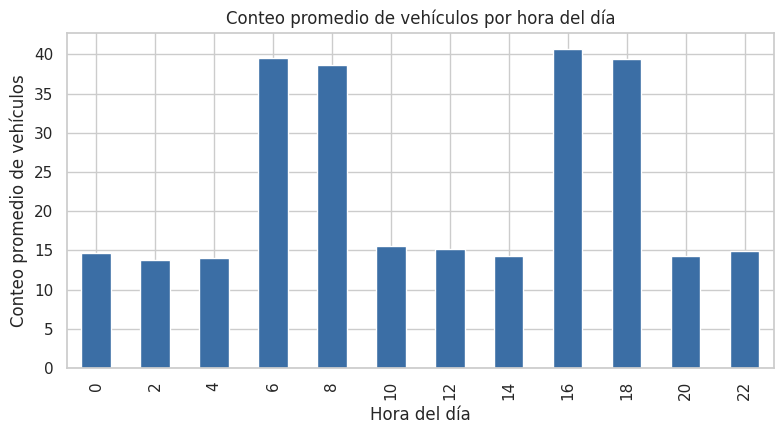

In [32]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df.groupby("hora")["conteo_vehiculos"].mean().plot(kind="bar", ax=ax, color="#3b6ea5")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Conteo promedio de vehículos")
ax.set_title("Conteo promedio de vehículos por hora del día")
plt.tight_layout()
plt.show()

## Recomendación grafica 3: Histograma de frecuencia de lecturas conteo de vehículos

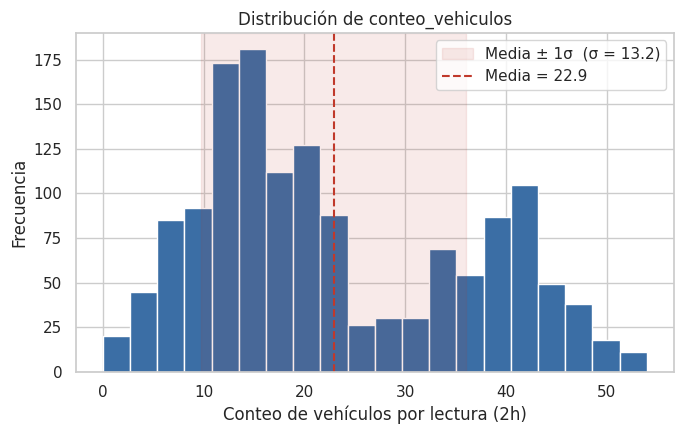

In [39]:
c = df["conteo_vehiculos"]
media, std = c.mean(), c.std()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(c, bins=20, color="#3b6ea5", edgecolor="white")
ax.set_xlabel("Conteo de vehículos por lectura (2h)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de conteo_vehiculos")

# Media y banda de ±1 desviación estándar (σ) — cuantifica la dispersión que sustenta 3.C.b
ax.axvspan(media - std, media + std, color="#c0392b", alpha=0.10,
           label=f"Media ± 1σ  (σ = {std:.1f})")
ax.axvline(media, color="#c0392b", linestyle="--", linewidth=1.5,
           label=f"Media = {media:.1f}")
ax.legend()
plt.tight_layout()
plt.show()

## Recomendación grafica 4: Promedio de veahículos contados por sensor.

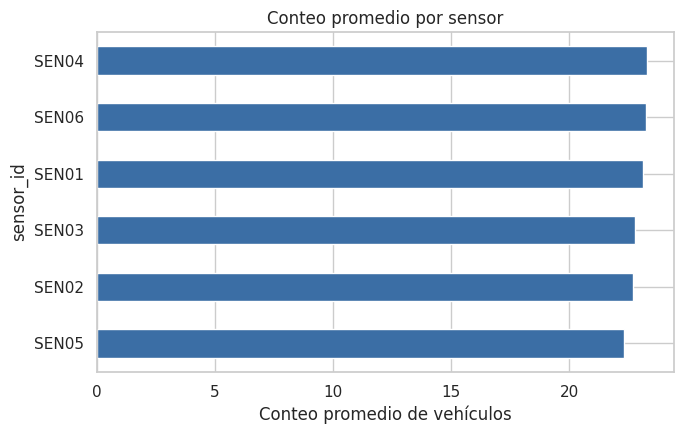

In [35]:
fig, ax = plt.subplots(figsize=(7, 4.5))
df.groupby("sensor_id")["conteo_vehiculos"].mean().sort_values().plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_xlabel("Conteo promedio de vehículos")
ax.set_title("Conteo promedio por sensor")
plt.tight_layout()
plt.show()